# 10.4 特征工程技术（约1.5课时）

> **学习目标：** 掌握数据竞赛中常用的特征工程技术，包括特征缩放、滑动窗口特征、池化操作、编码方法和统计矩特征提取。

---

## 一、特征工程概述

**特征工程**是机器学习竞赛中最关键的技术之一。俗话说：
> "数据和特征决定了机器学习的上限，而模型和算法只是逼近这个上限而已。"

### 特征工程的主要步骤

```
原始数据
  -> 数据清洗 (缺失值、异常值处理)
  -> 特征编码 (类别变量 -> 数值)
  -> 特征缩放 (标准化/归一化)
  -> 特征构造 (数学变换、滑动窗口、统计特征)
  -> 特征选择 (去除冗余、选择重要特征)
  -> 特征降维 (PCA、特征交叉)
```

### 本节涵盖的内容
1. **特征缩放**：StandardScaler、MinMaxScaler
2. **滑动窗口特征**：时间序列特征提取
3. **池化操作**：统计池化
4. **One-hot 编码**：独热编码
5. **统计矩特征**：均值、方差、偏度、峰度
6. **离散化与分箱**：Binning
7. **综合实战**


---
## 二、特征缩放

### 2.1 为什么需要特征缩放？

| 缩放方法 | 公式 | 范围 | 适用场景 |
|----------|------|------|----------|
| **标准化 (Z-score)** | $z = \frac{x - \mu}{\sigma}$ | 不固定（一般 [-3, 3]） | 大多数ML模型、神经网络 |
| **归一化 (Min-Max)** | $x' = \frac{x - x_{min}}{x_{max} - x_{min}}$ | [0, 1] | 图像像素、KNN、神经网络 |

> **注意**：树模型（决策树、随机森林、XGBoost）不需要特征缩放！

### 标准化 vs 归一化对比
```
标准化: 数据 -> 均值为0，标准差为1
归一化: 数据 -> [0, 1] 区间
```


In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

# ===== 创建示例数据 =====
np.random.seed(42)
data = pd.DataFrame({
    "年龄": np.random.randint(18, 65, 100),
    "收入": np.random.randint(3000, 50000, 100),
    "消费": np.random.randint(500, 10000, 100),
})
print("原始数据统计:")
print(data.describe().round(1))


原始数据统计:
          年龄       收入      消费
count  100.0    100.0   100.0
mean    40.9  26040.8  5277.6
std     14.0  13353.6  2587.4
min     18.0   3206.0   598.0
25%     30.5  15458.8  3045.5
50%     41.0  26509.0  5235.5
75%     53.2  35502.0  7243.8
max     64.0  49699.0  9992.0


In [2]:
# ===== 2.1 标准化 (StandardScaler) =====
scaler_std = StandardScaler()
data_std = scaler_std.fit_transform(data)
data_std = pd.DataFrame(data_std, columns=data.columns)

print("标准化后统计:")
print(data_std.describe().round(4))
print(f"\n各列均值: {data_std.mean().values.round(6)}")
print(f"各列标准差: {data_std.std().values.round(6)}")

# Scaler 参数
print(f"\nScaler mean_: {scaler_std.mean_.round(1)}")
print(f"Scaler scale_: {scaler_std.scale_.round(1)}")


标准化后统计:
             年龄        收入        消费
count  100.0000  100.0000  100.0000
mean    -0.0000    0.0000   -0.0000
std      1.0050    1.0050    1.0050
min     -1.6436   -1.7186   -1.8177
25%     -0.7457   -0.7964   -0.8670
50%      0.0086    0.0352   -0.0164
75%      0.8886    0.7121    0.7637
max      1.6608    1.7806    1.8312

各列均值: [-0.  0. -0.]
各列标准差: [1.005038 1.005038 1.005038]

Scaler mean_: [   40.9 26040.8  5277.6]
Scaler scale_: [   13.9 13286.7  2574.4]


归一化后统计:
             年龄        收入        消费
count  100.0000  100.0000  100.0000
mean     0.4974    0.4911    0.4982
std      0.3041    0.2872    0.2754
min      0.0000    0.0000    0.0000
25%      0.2717    0.2635    0.2605
50%      0.5000    0.5012    0.4937
75%      0.7663    0.6946    0.7074
max      1.0000    1.0000    1.0000

各列最小值: [0. 0. 0.]
各列最大值: [1. 1. 1.]


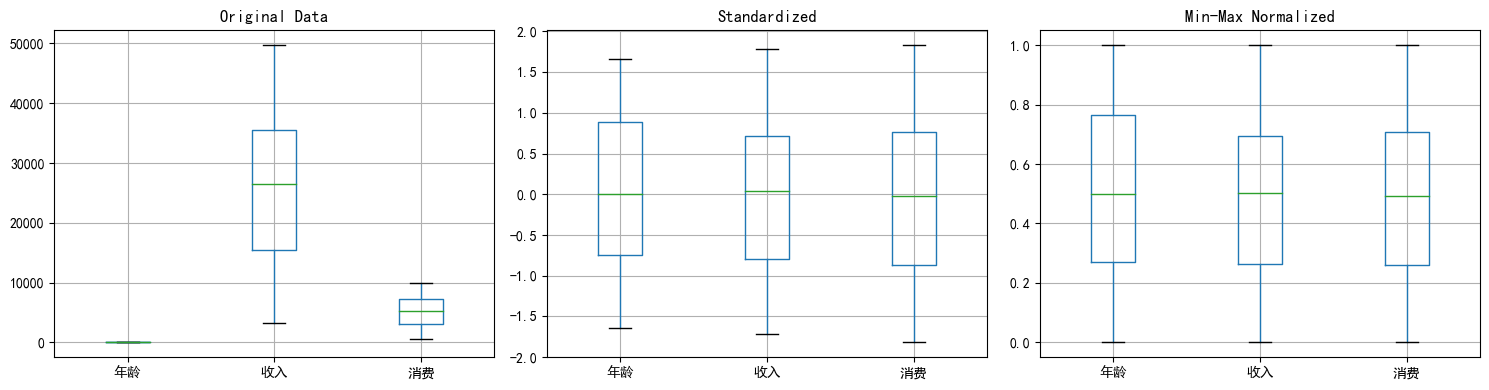

Figure saved!


In [3]:
# ===== 2.2 归一化 (MinMaxScaler) =====
scaler_mm = MinMaxScaler()
data_mm = scaler_mm.fit_transform(data)
data_mm = pd.DataFrame(data_mm, columns=data.columns)

print("归一化后统计:")
print(data_mm.describe().round(4))
print(f"\n各列最小值: {data_mm.min().values}")
print(f"各列最大值: {data_mm.max().values}")

# ===== 可视化对比 =====
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (df, title) in enumerate([
    (data, "Original Data"),
    (data_std, "Standardized"),
    (data_mm, "Min-Max Normalized")
]):
    df.boxplot(ax=axes[i])
    axes[i].set_title(title, fontsize=12)
plt.tight_layout()
plt.savefig("10_4_scaling_comparison.png", dpi=100, bbox_inches="tight")
plt.show()
print("Figure saved!")


In [4]:
# ===== 2.3 反标准化（还原原始数据） =====
data_restored = scaler_std.inverse_transform(data_std)
data_restored = pd.DataFrame(data_restored, columns=data.columns)
print("还原后数据 (应与原始数据相同):")
print(data_restored.describe().round(1))

# 验证
print("\n还原误差最大值:", np.max(np.abs(data.values - data_restored.values)))


还原后数据 (应与原始数据相同):
          年龄       收入      消费
count  100.0    100.0   100.0
mean    40.9  26040.8  5277.6
std     14.0  13353.6  2587.4
min     18.0   3206.0   598.0
25%     30.5  15458.8  3045.5
50%     41.0  26509.0  5235.5
75%     53.2  35502.0  7243.8
max     64.0  49699.0  9992.0

还原误差最大值: 4.547473508864641e-13


---
## 三、滑动窗口特征提取（时间序列）

### 原理
在时间序列数据中，当前时刻的值往往与过去若干时刻的值有关。滑动窗口通过在时间轴上"滑动"一个固定大小的窗口，提取统计特征。

```
时间序列: [x1, x2, x3, x4, x5, x6, x7, x8, ...]
窗口大小=3:
  窗口1: [x1, x2, x3] -> mean, std, max, min
  窗口2: [x2, x3, x4] -> mean, std, max, min
  窗口3: [x3, x4, x5] -> mean, std, max, min
  ...
```

### 常用滑动窗口特征
| 特征 | 说明 |
|------|------|
| 滑动均值 | 过去 N 步的平均值 |
| 滑动标准差 | 过去 N 步的波动性 |
| 滑动最大/最小值 | 过去 N 步的极值 |
| 滑动差分 | 当前值 - 前一个值 |
| EMA (指数移动平均) | 加权平均，近期权重更大 |


In [5]:
# ===== 滑动窗口特征提取 =====
np.random.seed(42)
n = 100
time = np.arange(n)
# 模拟传感器数据：趋势 + 周期 + 噪声
signal = np.cumsum(np.random.randn(n) * 0.5) + 10 + 3 * np.sin(time * 0.2) + np.random.randn(n) * 1.5

df_ts = pd.DataFrame({"时间": time, "信号值": signal})
print("原始数据 (前10行):")
print(df_ts.head(10))

# 滑动均值
window = 5
df_ts["滚动均值_5"] = df_ts["信号值"].rolling(window=window).mean()
# 滑动标准差
df_ts["滚动标准差_5"] = df_ts["信号值"].rolling(window=window).std()
# 滑动最大/最小值
df_ts["滚动最大_5"] = df_ts["信号值"].rolling(window=window).max()
df_ts["滚动最小_5"] = df_ts["信号值"].rolling(window=window).min()
# 差分
df_ts["一阶差分"] = df_ts["信号值"].diff(1)
# 指数移动平均 (EMA)
df_ts["EMA_10"] = df_ts["信号值"].ewm(span=10).mean()

print("\n提取特征后 (前15行):")
print(df_ts.dropna().head(15))


原始数据 (前10行):
   时间        信号值
0   0   8.125301
1   1  10.144265
2   2  11.157252
3   3  11.755096
4   4  13.057647
5   5  14.160928
6   6  17.445441
7   7  15.421979
8   8  15.354072
9   9  15.050180

提取特征后 (前15行):
    时间        信号值     滚动均值_5   滚动标准差_5     滚动最大_5     滚动最小_5      一阶差分  \
4    4  13.057647  10.847912  1.851306  13.057647   8.125301  1.302552   
5    5  14.160928  12.055038  1.580114  14.160928  10.144265  1.103281   
6    6  17.445441  13.515273  2.486514  17.445441  11.157252  3.284513   
7    7  15.421979  14.368218  2.189103  17.445441  11.755096 -2.023463   
8    8  15.354072  15.088013  1.637197  17.445441  13.057647 -0.067907   
9    9  15.050180  15.486520  1.204851  17.445441  14.160928 -0.303892   
10  10  11.858332  15.026001  2.009529  17.445441  11.858332 -3.191847   
11  11  14.161450  14.369203  1.490777  15.421979  11.858332  2.303118   
12  12  14.013448  14.087496  1.370319  15.354072  11.858332 -0.148002   
13  13  16.181440  14.252970  1.593312  16.18

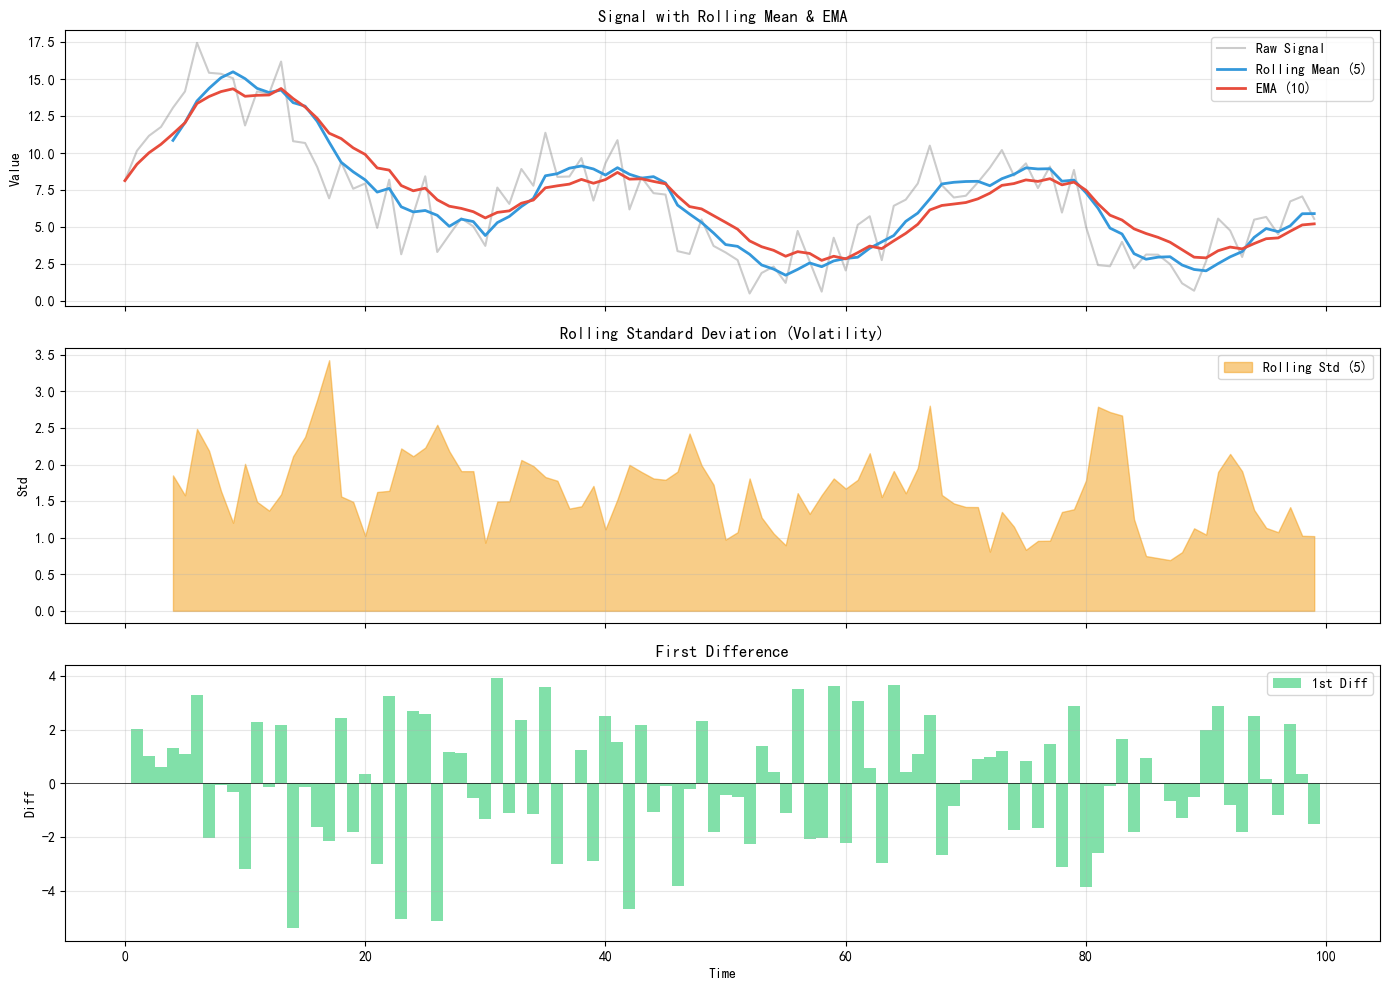

In [6]:
# ===== 滑动窗口特征可视化 =====
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# 子图1: 原始信号 + 滑动均值 + EMA
ax1 = axes[0]
ax1.plot(time, signal, alpha=0.4, label="Raw Signal", color="gray")
ax1.plot(time, df_ts["滚动均值_5"], label="Rolling Mean (5)", color="#3498db", linewidth=2)
ax1.plot(time, df_ts["EMA_10"], label="EMA (10)", color="#e74c3c", linewidth=2)
ax1.set_ylabel("Value")
ax1.set_title("Signal with Rolling Mean & EMA")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 子图2: 滑动标准差 (波动性)
ax2 = axes[1]
ax2.fill_between(time, 0, df_ts["滚动标准差_5"], alpha=0.5, color="#f39c12", label="Rolling Std (5)")
ax2.set_ylabel("Std")
ax2.set_title("Rolling Standard Deviation (Volatility)")
ax2.legend()
ax2.grid(True, alpha=0.3)

# 子图3: 差分 (变化量)
ax3 = axes[2]
ax3.bar(time, df_ts["一阶差分"], color="#2ecc71", alpha=0.6, width=1.0, label="1st Diff")
ax3.axhline(y=0, color="black", linewidth=0.5)
ax3.set_ylabel("Diff")
ax3.set_xlabel("Time")
ax3.set_title("First Difference")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("10_4_rolling_features.png", dpi=100, bbox_inches="tight")
plt.show()


---
## 四、池化操作（统计池化）

### 原理
池化（Pooling）操作将数据划分为固定大小的窗口，对每个窗口内的数据进行统计聚合，从而**降低数据分辨率**同时**提取局部特征**。

### 常用池化方式
| 池化类型 | 操作 | 公式 |
|----------|------|------|
| **均值池化** | 取窗口均值 | $y = \frac{1}{n}\sum_{i} x_i$ |
| **最大池化** | 取窗口最大值 | $y = \max(x_i)$ |
| **最小池化** | 取窗口最小值 | $y = \min(x_i)$ |
| **中位数池化** | 取窗口中位数 | $y = \text{median}(x_i)$ |

> **滑动窗口 vs 池化**：滑动窗口产生与原始数据等长的输出（有重叠），池化产生缩短的输出（无重叠）。


In [7]:
# ===== 池化操作演示 =====
np.random.seed(42)

# 1D 数据的池化
signal_1d = np.random.randn(60) * 5 + 10
window_size = 5

def pool_1d(data, pool_size, method="mean"):
    # 1D 池化操作
    n = len(data)
    n_pools = n // pool_size
    pooled = np.zeros(n_pools)
    for i in range(n_pools):
        chunk = data[i * pool_size : (i + 1) * pool_size]
        if method == "mean":
            pooled[i] = chunk.mean()
        elif method == "max":
            pooled[i] = chunk.max()
        elif method == "min":
            pooled[i] = chunk.min()
        elif method == "median":
            pooled[i] = np.median(chunk)
    return pooled

# 对同一信号应用不同池化
pooled_mean = pool_1d(signal_1d, window_size, "mean")
pooled_max = pool_1d(signal_1d, window_size, "max")
pooled_min = pool_1d(signal_1d, window_size, "min")

print(f"原始数据长度: {len(signal_1d)}")
print(f"池化后数据长度: {len(pooled_mean)}")
print(f"均值池化前5个: {pooled_mean[:5].round(2)}")
print(f"最大池化前5个: {pooled_max[:5].round(2)}")
print(f"最小池化前5个: {pooled_min[:5].round(2)}")


原始数据长度: 60
池化后数据长度: 12
均值池化前5个: [12.3  12.19  5.67  6.42  9.34]
最大池化前5个: [17.62 17.9  11.21 11.57 17.33]
最小池化前5个: [8.83 7.65 0.43 2.94 2.88]


In [8]:
# ===== 2D 数据的池化（图像数据）=====
import numpy as np

# 创建一个简单的 8x8 图像数据
np.random.seed(42)
image = np.random.randint(0, 256, (8, 8))
print("原始图像 (8x8):")
print(image)

def pool_2d(data, pool_size, method="max"):
    # 2D 池化操作
    h, w = data.shape
    h_out = h // pool_size
    w_out = w // pool_size
    pooled = np.zeros((h_out, w_out))
    for i in range(h_out):
        for j in range(w_out):
            chunk = data[i*pool_size:(i+1)*pool_size, j*pool_size:(j+1)*pool_size]
            if method == "max":
                pooled[i, j] = chunk.max()
            elif method == "mean":
                pooled[i, j] = chunk.mean()
    return pooled

pooled_2x2 = pool_2d(image, 2, "max")
print("\n2x2 最大池化后 (4x4):")
print(pooled_2x2.astype(int))

# 池化缩小了数据维度：8x8 -> 4x4
print(f"\n维度变化: {image.shape} -> {pooled_2x2.shape}")


原始图像 (8x8):
[[102 179  92  14 106  71 188  20]
 [102 121 210 214  74 202  87 116]
 [ 99 103 151 130 149  52   1  87]
 [235 157  37 129 191 187  20 160]
 [203  57  21 252 235  88  48 218]
 [ 58 254 169 255 219 187 207  14]
 [189 189 174 189  50 107  54 243]
 [ 63 248 130 228  50 134  20  72]]

2x2 最大池化后 (4x4):
[[179 214 202 188]
 [235 151 191 160]
 [254 255 235 218]
 [248 228 134 243]]

维度变化: (8, 8) -> (4, 4)


In [9]:
# ===== 使用 NumPy reshape 实现高效池化 =====
def pool_2d_fast(data, pool_size, method="max"):
    # 使用 reshape 实现高效 2D 池化
    h, w = data.shape
    h_out = h // pool_size
    w_out = w // pool_size
    # 将数据 reshape 为 (h_out, pool_size, w_out, pool_size)
    reshaped = data[:h_out*pool_size, :w_out*pool_size].reshape(h_out, pool_size, w_out, pool_size)
    # 转置为 (h_out, w_out, pool_size, pool_size)
    reshaped = reshaped.transpose(0, 2, 1, 3)
    # 合并后两维
    final = reshaped.reshape(h_out, w_out, -1)
    if method == "max":
        return final.max(axis=-1)
    elif method == "mean":
        return final.mean(axis=-1)
    elif method == "min":
        return final.min(axis=-1)

# 验证结果一致
result_fast = pool_2d_fast(image, 2, "max")
print("高效池化结果:")
print(result_fast.astype(int))
print(f"\n与之前结果一致: {np.array_equal(result_fast, pooled_2x2)}")


高效池化结果:
[[179 214 202 188]
 [235 151 191 160]
 [254 255 235 218]
 [248 228 134 243]]

与之前结果一致: True


---
## 五、One-hot 编码（独热编码）

### 原理
将类别变量转换为二进制向量，每个类别对应一个独立的位。

```
颜色: ["红", "绿", "蓝"]
红色 -> [1, 0, 0]
绿色 -> [0, 1, 0]
蓝色 -> [0, 0, 1]
```

### 何时使用 One-hot？
| 编码方式 | 适用场景 |
|----------|----------|
| **Label Encoding** | 有序类别（如：低、中、高） |
| **One-hot Encoding** | 无序类别（如：红、绿、蓝） |

> **注意**：类别数量很多时（如 >100），One-hot 会导致维度爆炸，考虑使用 Embedding。


In [10]:
# ===== One-hot 编码 =====
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# 示例数据
df = pd.DataFrame({
    "姓名": ["张三", "李四", "王五", "赵六", "孙七"],
    "性别": ["男", "女", "男", "女", "男"],
    "城市": ["北京", "上海", "广州", "北京", "上海"],
    "等级": ["A", "B", "A", "C", "B"]
})
print("原始数据:")
print(df)

# 方法1: Pandas get_dummies（最简单）
print("\n--- Pandas get_dummies ---")
df_dummies = pd.get_dummies(df, columns=["性别", "城市", "等级"])
print(df_dummies)


原始数据:
   姓名 性别  城市 等级
0  张三  男  北京  A
1  李四  女  上海  B
2  王五  男  广州  A
3  赵六  女  北京  C
4  孙七  男  上海  B

--- Pandas get_dummies ---
   姓名   性别_女   性别_男  城市_上海  城市_北京  城市_广州   等级_A   等级_B   等级_C
0  张三  False   True  False   True  False   True  False  False
1  李四   True  False   True  False  False  False   True  False
2  王五  False   True  False  False   True   True  False  False
3  赵六   True  False  False   True  False  False  False   True
4  孙七  False   True   True  False  False  False   True  False


In [11]:
# ===== 方法2: sklearn OneHotEncoder（推荐，可保存模型）=====
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

# 对类别列进行编码
cat_cols = ["性别", "城市", "等级"]
encoded = encoder.fit_transform(df[cat_cols])

# 获取编码后的列名
encoded_cols = encoder.get_feature_names_out(cat_cols)
print("编码后的列名:", encoded_cols)

# 拼接回原始数据（去掉原始类别列）
df_encoded = pd.concat([
    df.drop(columns=cat_cols),
    pd.DataFrame(encoded, columns=encoded_cols)
], axis=1)
print("\nsklearn OneHotEncoder 结果:")
print(df_encoded)

# ===== Label Encoding（有序类别）=====
print("\n--- Label Encoding（等级列） ---")
le = LabelEncoder()
df["等级_LabelEnc"] = le.fit_transform(df["等级"])
print(df[["姓名", "等级", "等级_LabelEnc"]])
print(f"映射: {dict(zip(le.classes_, le.transform(le.classes_)))}")


编码后的列名: ['性别_女' '性别_男' '城市_上海' '城市_北京' '城市_广州' '等级_A' '等级_B' '等级_C']

sklearn OneHotEncoder 结果:
   姓名  性别_女  性别_男  城市_上海  城市_北京  城市_广州  等级_A  等级_B  等级_C
0  张三   0.0   1.0    0.0    1.0    0.0   1.0   0.0   0.0
1  李四   1.0   0.0    1.0    0.0    0.0   0.0   1.0   0.0
2  王五   0.0   1.0    0.0    0.0    1.0   1.0   0.0   0.0
3  赵六   1.0   0.0    0.0    1.0    0.0   0.0   0.0   1.0
4  孙七   0.0   1.0    1.0    0.0    0.0   0.0   1.0   0.0

--- Label Encoding（等级列） ---
   姓名 等级  等级_LabelEnc
0  张三  A            0
1  李四  B            1
2  王五  A            0
3  赵六  C            2
4  孙七  B            1
映射: {'A': 0, 'B': 1, 'C': 2}


---
## 六、统计矩特征提取

### 高阶统计量
在数据竞赛中，除了基本的均值和方差，**偏度（Skewness）** 和 **峰度（Kurtosis）** 也是非常重要的特征。

| 统计量 | 公式 | 含义 |
|--------|------|------|
| **均值 (Mean)** | $\bar{x} = \frac{1}{n}\sum x_i$ | 中心位置 |
| **方差 (Variance)** | $\sigma^2 = \frac{1}{n}\sum(x_i - \bar{x})^2$ | 离散程度 |
| **偏度 (Skewness)** | $S = \frac{1}{n}\sum(\frac{x_i - \bar{x}}{\sigma})^3$ | 分布不对称性 |
| **峰度 (Kurtosis)** | $K = \frac{1}{n}\sum(\frac{x_i - \bar{x}}{\sigma})^4 - 3$ | 尖峰/尾部特征 |

### 偏度解读
- **偏度 > 0**：右偏（长尾在右，多数值在左侧）
- **偏度 < 0**：左偏（长尾在左，多数值在右侧）
- **偏度 = 0**：对称分布（如正态分布）

### 峰度解读
- **峰度 > 0**：尖峰分布（比正态分布更尖，尾部更厚）
- **峰度 < 0**：平坦分布（比正态分布更平）
- **峰度 = 0**：与正态分布相同


In [12]:
# ===== 统计矩特征提取 =====
from scipy import stats

np.random.seed(42)

# 生成不同分布的数据
n = 1000
normal = np.random.randn(n)               # 标准正态
right_skew = np.random.exponential(1, n)  # 右偏（指数分布）
left_skew = -np.random.exponential(1, n) + 5  # 左偏
high_kurt = np.random.laplace(0, 1, n)    # 高峰度（拉普拉斯分布）
uniform = np.random.uniform(-3, 3, n)     # 均匀分布

distributions = {
    "正态分布": normal,
    "右偏分布": right_skew,
    "左偏分布": left_skew,
    "高峰度": high_kurt,
    "均匀分布": uniform,
}

print("各分布的统计矩特征:")
print("-" * 65)
print(f"{'分布':<8} {'均值':>8} {'标准差':>8} {'偏度':>8} {'峰度':>8}")
print("-" * 65)
for name, data_dist in distributions.items():
    mean = np.mean(data_dist)
    std = np.std(data_dist)
    skew = stats.skew(data_dist)
    kurt = stats.kurtosis(data_dist)  # excess kurtosis
    print(f"{name:<8} {mean:>8.2f} {std:>8.2f} {skew:>8.2f} {kurt:>8.2f}")


各分布的统计矩特征:
-----------------------------------------------------------------
分布             均值      标准差       偏度       峰度
-----------------------------------------------------------------
正态分布         0.02     0.98     0.12     0.07
右偏分布         1.01     1.00     1.98     5.38
左偏分布         4.03     0.94    -1.64     3.00
高峰度         -0.03     1.43    -0.07     4.61
均匀分布        -0.03     1.73     0.05    -1.21


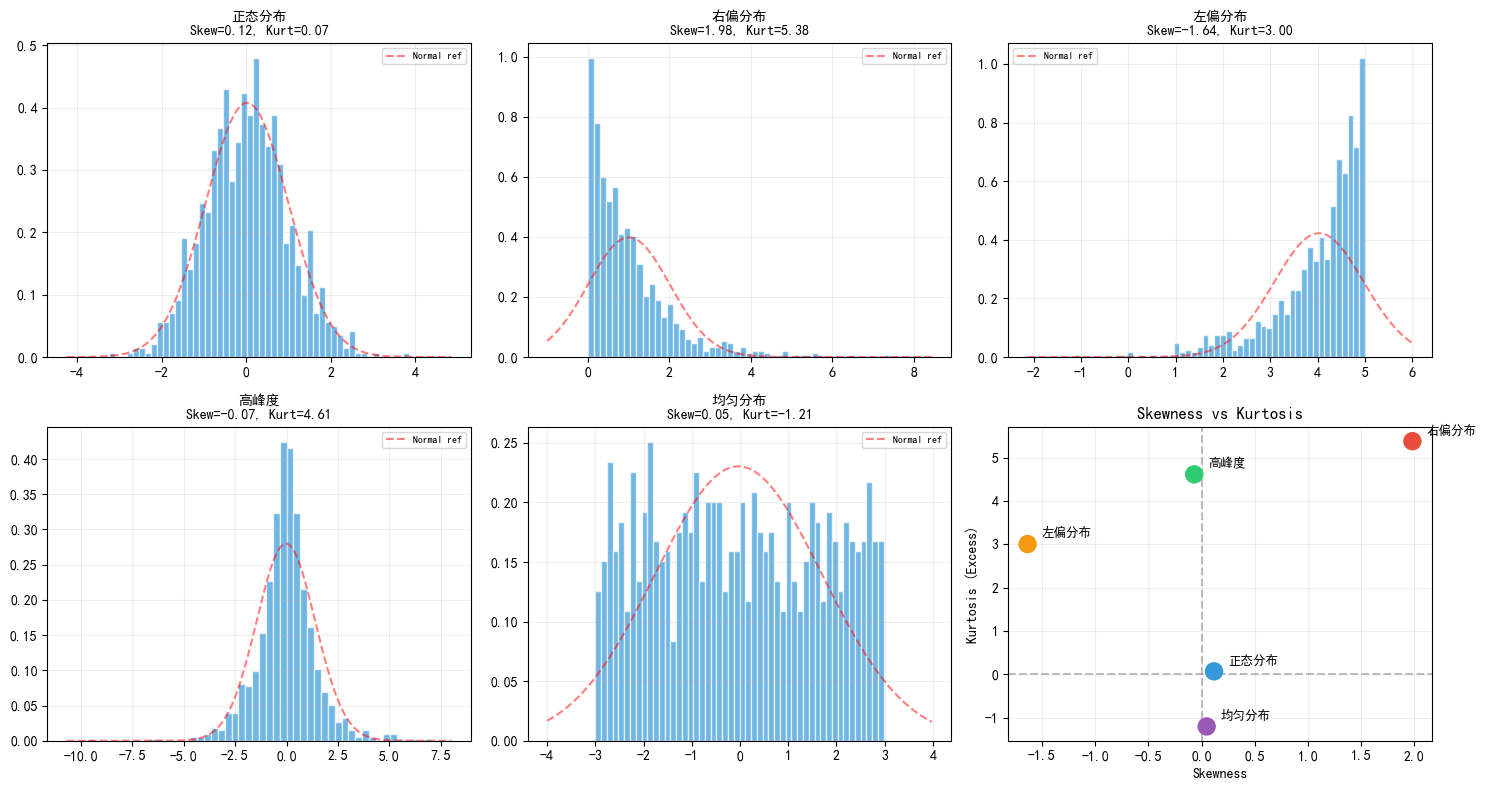

In [13]:
# ===== 统计矩特征可视化 =====
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for idx, (name, data_dist) in enumerate(distributions.items()):
    ax = axes[idx // 3, idx % 3]
    ax.hist(data_dist, bins=50, density=True, alpha=0.7, color="#3498db", edgecolor="white")
    
    # 叠加理论正态分布（参考）
    x_range = np.linspace(data_dist.min() - 1, data_dist.max() + 1, 200)
    ax.plot(x_range, stats.norm.pdf(x_range, data_dist.mean(), data_dist.std()),
            "r--", alpha=0.5, label="Normal ref")
    
    skew = stats.skew(data_dist)
    kurt = stats.kurtosis(data_dist)
    ax.set_title(f"{name}\nSkew={skew:.2f}, Kurt={kurt:.2f}", fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.2)

# 第6个子图：偏度vs峰度散点图
ax6 = axes[1, 2]
skews = [stats.skew(d) for d in distributions.values()]
kurts = [stats.kurtosis(d) for d in distributions.values()]
colors = ["#3498db", "#e74c3c", "#f39c12", "#2ecc71", "#9b59b6"]
ax6.scatter(skews, kurts, c=colors, s=150, zorder=5)
for i, name in enumerate(distributions.keys()):
    ax6.annotate(name, (skews[i], kurts[i]), textcoords="offset points",
                 xytext=(10, 5), fontsize=9)
ax6.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax6.axvline(x=0, color="gray", linestyle="--", alpha=0.5)
ax6.set_xlabel("Skewness")
ax6.set_ylabel("Kurtosis (Excess)")
ax6.set_title("Skewness vs Kurtosis")
ax6.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("10_4_statistical_moments.png", dpi=100, bbox_inches="tight")
plt.show()


---
## 七、离散化与分箱（Binning）

### 原理
将连续变量划分为若干离散的区间（"箱子"），每个样本只属于一个箱子。

### 为什么要分箱？
1. **处理非线性关系**：如年龄与收入的关系可能是非线性的，分箱后每个区间可独立学习
2. **降低噪声影响**：区间内的微小波动被平滑
3. **提高模型鲁棒性**：减少极端值的影响

### 分箱方式
| 方式 | 方法 | 说明 |
|------|------|------|
| **等宽分箱** | `pd.cut()` | 每个箱子宽度相同 |
| **等频分箱** | `pd.qcut()` | 每个箱子样本数相同 |
| **自定义分箱** | `pd.cut(bins=[...])` | 手动指定边界 |
| **决策树分箱** | `DecisionTree` | 用树模型自动寻找最优分箱点 |


In [14]:
# ===== 离散化与分箱 =====
import numpy as np
import pandas as pd

np.random.seed(42)
ages = np.random.randint(18, 70, 200)
scores = np.random.randint(0, 100, 200)

df_bin = pd.DataFrame({"年龄": ages, "成绩": scores})
print("原始数据统计:")
print(df_bin.describe())


原始数据统计:
              年龄          成绩
count  200.00000  200.000000
mean    43.42500   49.580000
std     14.94191   29.693808
min     18.00000    0.000000
25%     31.00000   23.750000
50%     43.50000   49.500000
75%     56.00000   72.500000
max     69.00000   99.000000


In [15]:
# ===== 1. 等宽分箱 (Equal Width) =====
# pd.cut: 按值域等分
df_bin["年龄_等宽"] = pd.cut(df_bin["年龄"], bins=5)
print("等宽分箱结果:")
print(df_bin["年龄_等宽"].value_counts().sort_index())

# 自定义分箱边界
df_bin["年龄_自定义"] = pd.cut(
    df_bin["年龄"],
    bins=[0, 18, 25, 35, 50, 100],
    labels=["青少年", "青年", "壮年", "中年", "老年"]
)
print("\n自定义分箱结果:")
print(df_bin["年龄_自定义"].value_counts().sort_index())


等宽分箱结果:
年龄_等宽
(17.949, 28.2]    43
(28.2, 38.4]      32
(38.4, 48.6]      44
(48.6, 58.8]      40
(58.8, 69.0]      41
Name: count, dtype: int64

自定义分箱结果:
年龄_自定义
青少年     5
青年     28
壮年     35
中年     58
老年     74
Name: count, dtype: int64


In [16]:
# ===== 2. 等频分箱 (Equal Frequency) =====
# pd.qcut: 按分位数分，每个箱样本数大致相同
df_bin["成绩_等频"] = pd.qcut(df_bin["成绩"], q=5, labels=["F", "D", "C", "B", "A"])
print("等频分箱结果:")
print(df_bin["成绩_等频"].value_counts().sort_index())


等频分箱结果:
成绩_等频
F    40
D    42
C    41
B    37
A    40
Name: count, dtype: int64


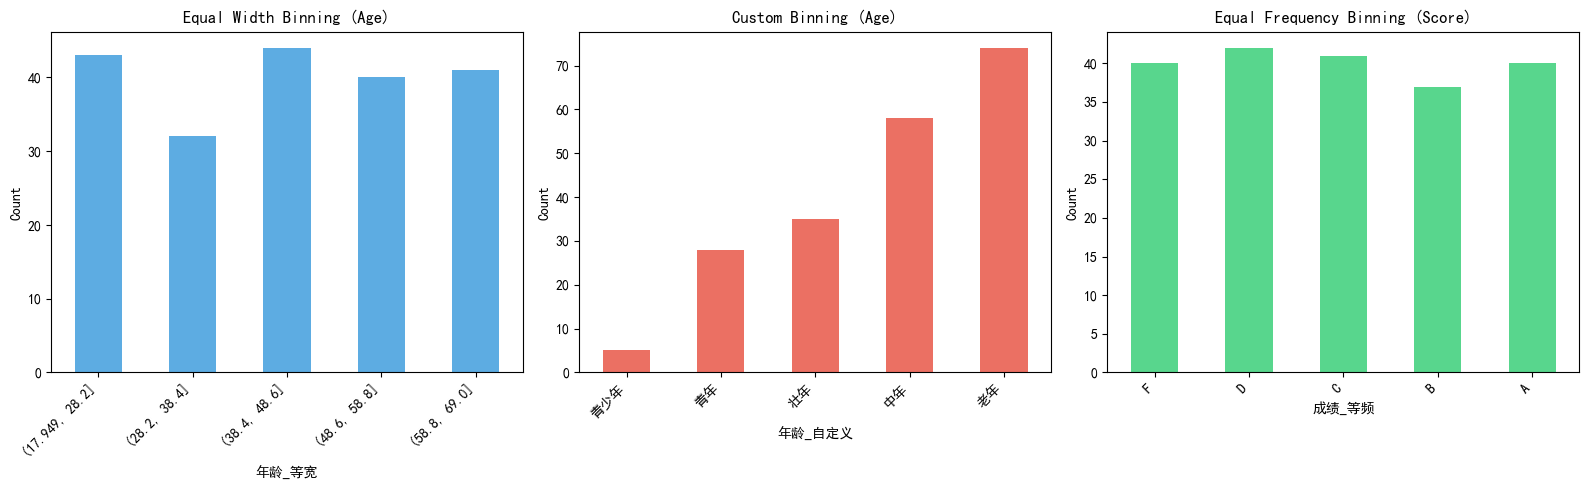

In [17]:
# ===== 3. 分箱可视化 =====
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 等宽分箱直方图
ax1 = axes[0]
df_bin["年龄_等宽"].value_counts().sort_index().plot(kind="bar", ax=ax1, color="#3498db", alpha=0.8)
ax1.set_title("Equal Width Binning (Age)", fontsize=12)
ax1.set_ylabel("Count")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")

# 自定义分箱直方图
ax2 = axes[1]
df_bin["年龄_自定义"].value_counts().sort_index().plot(kind="bar", ax=ax2, color="#e74c3c", alpha=0.8)
ax2.set_title("Custom Binning (Age)", fontsize=12)
ax2.set_ylabel("Count")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="right")

# 等频分箱直方图
ax3 = axes[2]
df_bin["成绩_等频"].value_counts().sort_index().plot(kind="bar", ax=ax3, color="#2ecc71", alpha=0.8)
ax3.set_title("Equal Frequency Binning (Score)", fontsize=12)
ax3.set_ylabel("Count")
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig("10_4_binning.png", dpi=100, bbox_inches="tight")
plt.show()


---
## 八、特征工程综合实战

将本节学到的所有技术组合起来，对一个模拟数据集进行完整的特征工程流程。


In [18]:
# ===== 特征工程综合实战 =====
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from scipy import stats
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

np.random.seed(42)
n = 200

# 模拟传感器设备数据
df_raw = pd.DataFrame({
    "设备ID": np.random.choice(["DEV_A", "DEV_B", "DEV_C", "DEV_D"], n),
    "温度": np.random.normal(25, 5, n),
    "湿度": np.random.normal(60, 15, n),
    "压力": np.random.normal(1013, 20, n),
    "电压": np.random.uniform(3.0, 5.0, n),
    "运行状态": np.random.choice(["正常", "告警", "故障"], n, p=[0.8, 0.15, 0.05]),
})

print("原始数据形状:", df_raw.shape)
print(df_raw.head())


原始数据形状: (200, 6)
    设备ID         温度         湿度           压力        电压 运行状态
0  DEV_C  25.435235  62.985895  1024.531139  4.287999   正常
1  DEV_D  23.504963  50.996747  1019.225003  3.817468   正常
2  DEV_A  25.458804  61.047031  1074.577616  3.050773   故障
3  DEV_C  15.062155  54.220296  1035.391498  3.312305   正常
4  DEV_C  23.901641  61.702760  1010.441648  4.431944   正常


In [19]:
# ===== Step 1: 特征编码 =====
print("=" * 50)
print("Step 1: 特征编码")
print("=" * 50)

# One-hot 编码
df_features = df_raw.copy()
df_dummies = pd.get_dummies(df_features[["设备ID", "运行状态"]], prefix=["设备", "状态"])
df_features = pd.concat([df_features, df_dummies], axis=1)

print("One-hot 编码后的列:", [c for c in df_features.columns if c.startswith("设备") or c.startswith("状态")])
print(f"特征数: {len(df_features.columns)}")


Step 1: 特征编码
One-hot 编码后的列: ['设备ID', '设备_DEV_A', '设备_DEV_B', '设备_DEV_C', '设备_DEV_D', '状态_告警', '状态_故障', '状态_正常']
特征数: 13


In [20]:
# ===== Step 2: 特征缩放 =====
print("=" * 50)
print("Step 2: 特征缩放")
print("=" * 50)

numeric_cols = ["温度", "湿度", "压力", "电压"]
scaler = StandardScaler()
df_features[numeric_cols] = scaler.fit_transform(df_features[numeric_cols])

print("标准化后数值列统计:")
print(df_features[numeric_cols].describe().round(3))


Step 2: 特征缩放
标准化后数值列统计:
            温度       湿度       压力       电压
count  200.000  200.000  200.000  200.000
mean    -0.000    0.000    0.000    0.000
std      1.003    1.003    1.003    1.003
min     -3.245   -2.485   -2.565   -1.623
25%     -0.734   -0.675   -0.689   -0.853
50%      0.048   -0.020   -0.003    0.002
75%      0.607    0.668    0.612    0.837
max      3.818    2.290    3.048    1.736


In [21]:
# ===== Step 3: 统计矩特征 =====
print("=" * 50)
print("Step 3: 统计矩特征")
print("=" * 50)

for col in numeric_cols:
    values = df_features[col]
    df_features[f"{col}_偏度"] = values.skew()
    df_features[f"{col}_峰度"] = values.kurtosis()

# 偏度和峰度是全局统计量，对所有样本相同
print("新增全局特征:")
print([c for c in df_features.columns if "偏度" in c or "峰度" in c])


Step 3: 统计矩特征
新增全局特征:
['温度_偏度', '温度_峰度', '湿度_偏度', '湿度_峰度', '压力_偏度', '压力_峰度', '电压_偏度', '电压_峰度']


In [22]:
# ===== Step 4: 特征交互（交叉特征）=====
print("=" * 50)
print("Step 4: 特征交互")
print("=" * 50)

# 温湿指数 (THI) - 真实的气象指标
# THI = T - 0.55 * (1 - RH/100) * (T - 14.5)
# 这里用标准化后的值做简单的交互特征
df_features["温度_x_湿度"] = df_features["温度"] * df_features["湿度"]
df_features["温度_x_电压"] = df_features["温度"] * df_features["电压"]
df_features["温度_平方"] = df_features["温度"] ** 2
df_features["湿度_log"] = np.log1p(df_features["湿度"].abs())

print("新增交互特征:")
print([c for c in df_features.columns if c not in df_raw.columns and "设备" not in c and "状态" not in c and "偏度" not in c and "峰度" not in c])


Step 4: 特征交互
新增交互特征:
['温度_x_湿度', '温度_x_电压', '温度_平方', '湿度_log']


In [23]:
# ===== Step 5: 分箱特征 =====
print("=" * 50)
print("Step 5: 分箱特征")
print("=" * 50)

# 用原始温度进行分箱（标准化后不适合分箱）
df_features["温度区间"] = pd.cut(
    df_raw["温度"], bins=5, labels=["极低", "低", "中", "高", "极高"]
)
df_features["电压等级"] = pd.qcut(
    df_raw["电压"], q=3, labels=["低电压", "中电压", "高电压"]
)

print("温度区间分布:")
print(df_features["温度区间"].value_counts().sort_index())
print("\n电压等级分布:")
print(df_features["电压等级"].value_counts().sort_index())


Step 5: 分箱特征
温度区间分布:
温度区间
极低      5
低      65
中     103
高      24
极高      3
Name: count, dtype: int64

电压等级分布:
电压等级
低电压    67
中电压    66
高电压    67
Name: count, dtype: int64


In [24]:
# ===== Step 6: 最终特征矩阵 =====
print("=" * 50)
print("Step 6: 最终特征矩阵")
print("=" * 50)

# 选择所有数值列作为最终特征
feature_cols = [c for c in df_features.columns if df_features[c].dtype in [np.float64, np.int64, np.float32, np.int32, bool]]
print(f"最终数值特征数量: {len(feature_cols)}")
print(f"特征列: {feature_cols}")

X = df_features[feature_cols].values
print(f"\n特征矩阵形状: {X.shape}")

# 特征重要性可视化（简单方差分析）
variances = np.var(X, axis=0)
top_features_idx = np.argsort(variances)[::-1][:10]
print("\n方差最大的10个特征:")
for idx in top_features_idx:
    print(f"  {feature_cols[idx]:20s} 方差={variances[idx]:.4f}")


Step 6: 最终特征矩阵
最终数值特征数量: 23
特征列: ['温度', '湿度', '压力', '电压', '设备_DEV_A', '设备_DEV_B', '设备_DEV_C', '设备_DEV_D', '状态_告警', '状态_故障', '状态_正常', '温度_偏度', '温度_峰度', '湿度_偏度', '湿度_峰度', '压力_偏度', '压力_峰度', '电压_偏度', '电压_峰度', '温度_x_湿度', '温度_x_电压', '温度_平方', '湿度_log']

特征矩阵形状: (200, 23)

方差最大的10个特征:
  温度_平方                方差=2.7925
  温度_x_湿度              方差=1.1070
  温度                   方差=1.0000
  压力                   方差=1.0000
  电压                   方差=1.0000
  湿度                   方差=1.0000
  温度_x_电压              方差=0.9331
  设备_DEV_C             方差=0.1971
  设备_DEV_D             方差=0.1971
  设备_DEV_B             方差=0.1771


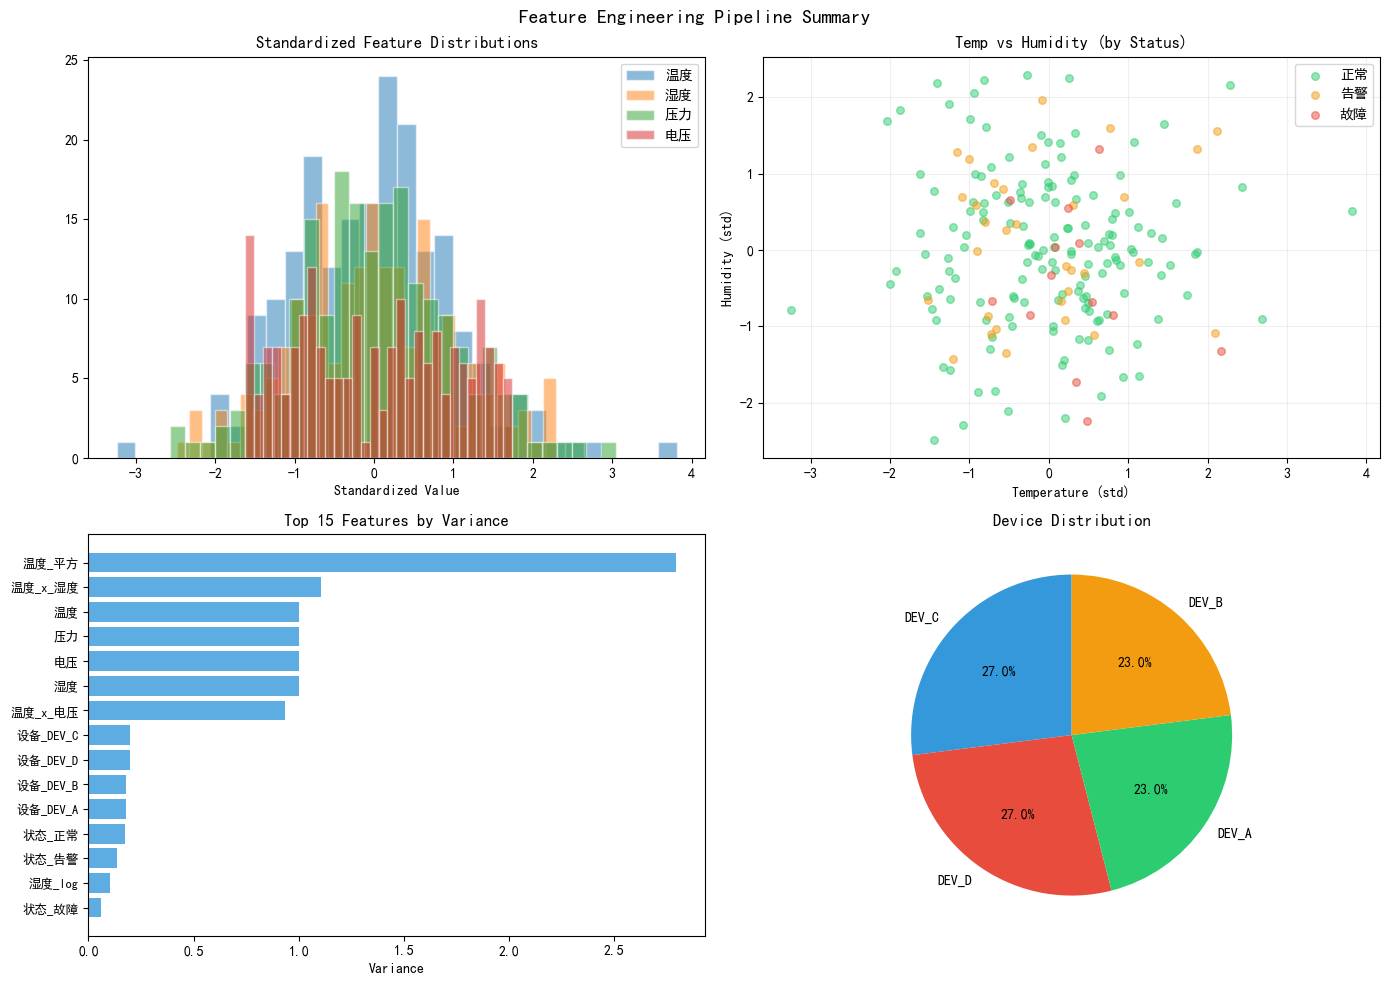

Figure saved as 10_4_feature_engineering_summary.png


In [25]:
# ===== 最终特征工程结果可视化 =====
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 标准化后的数据分布
ax1 = axes[0, 0]
for i, col in enumerate(numeric_cols):
    ax1.hist(df_features[col], bins=30, alpha=0.5, label=col, edgecolor="white")
ax1.set_title("Standardized Feature Distributions", fontsize=12)
ax1.legend()
ax1.set_xlabel("Standardized Value")

# 2. 特征交互散点图
ax2 = axes[0, 1]
colors_plot = {"正常": "#2ecc71", "告警": "#f39c12", "故障": "#e74c3c"}
for status, color in colors_plot.items():
    mask = df_raw["运行状态"] == status
    ax2.scatter(df_features.loc[mask, "温度"], df_features.loc[mask, "湿度"],
                c=color, label=status, alpha=0.5, s=30)
ax2.set_title("Temp vs Humidity (by Status)", fontsize=12)
ax2.set_xlabel("Temperature (std)")
ax2.set_ylabel("Humidity (std)")
ax2.legend()
ax2.grid(True, alpha=0.2)

# 3. 方差最大的特征柱状图
ax3 = axes[1, 0]
top_n = 15
top_idx = np.argsort(variances)[::-1][:top_n]
top_names = [feature_cols[i] for i in top_idx]
top_vars = variances[top_idx]
ax3.barh(range(top_n), top_vars, color="#3498db", alpha=0.8)
ax3.set_yticks(range(top_n))
ax3.set_yticklabels(top_names, fontsize=9)
ax3.set_xlabel("Variance")
ax3.set_title("Top 15 Features by Variance", fontsize=12)
ax3.invert_yaxis()

# 4. 设备分布饼图
ax4 = axes[1, 1]
device_counts = df_raw["设备ID"].value_counts()
ax4.pie(device_counts, labels=device_counts.index, autopct="%1.1f%%",
        colors=["#3498db", "#e74c3c", "#2ecc71", "#f39c12"], startangle=90)
ax4.set_title("Device Distribution", fontsize=12)

plt.suptitle("Feature Engineering Pipeline Summary", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("10_4_feature_engineering_summary.png", dpi=100, bbox_inches="tight")
plt.show()
print("Figure saved as 10_4_feature_engineering_summary.png")


---
## 练习题

### 练习1：特征缩放
对以下数据分别使用 StandardScaler 和 MinMaxScaler 进行缩放，并比较结果：
```python
data = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
```

### 练习2：滑动窗口特征
给定一组时间序列数据，提取以下特征：
- 窗口大小为 3 的滑动均值
- 窗口大小为 5 的滑动标准差
- EMA（span=10）

### 练习3：One-hot 编码 + 标准化
创建一个 DataFrame（含数值列和类别列），完成：
1. 对类别列进行 One-hot 编码
2. 对数值列进行标准化
3. 输出最终特征矩阵的形状

### 练习4：统计矩特征 + 分箱
生成一组偏态分布数据（如对数正态分布），计算其四阶统计矩（均值、标准差、偏度、峰度），并进行等频分箱。


In [26]:
# ===== 练习题参考答案 =====

# --- 练习1 ---
print("===== 练习1 =====")
data = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100]).reshape(-1, 1)
from sklearn.preprocessing import StandardScaler, MinMaxScaler

std_scaled = StandardScaler().fit_transform(data).flatten()
mm_scaled = MinMaxScaler().fit_transform(data).flatten()

print("原始:", data.flatten())
print("标准化:", np.round(std_scaled, 2))
print("归一化:", np.round(mm_scaled, 2))

# --- 练习2 ---
print("\n===== 练习2 =====")
ts = pd.Series(np.cumsum(np.random.randn(50) * 2 + 0.5))
print("滑动均值(3):")
print(ts.rolling(3).mean().values[:10].round(2))
print("滑动标准差(5):")
print(ts.rolling(5).std().values[:10].round(2))
print("EMA(10):")
print(ts.ewm(span=10).mean().values[:10].round(2))

# --- 练习3 ---
print("\n===== 练习3 =====")
df_ex = pd.DataFrame({
    "身高": np.random.normal(170, 10, 50),
    "体重": np.random.normal(65, 8, 50),
    "性别": np.random.choice(["男", "女"], 50),
    "血型": np.random.choice(["A", "B", "AB", "O"], 50),
})
# One-hot
df_onehot = pd.get_dummies(df_ex[["性别", "血型"]])
# 标准化
num_cols = ["身高", "体重"]
df_ex[num_cols] = StandardScaler().fit_transform(df_ex[num_cols])
# 合并
df_final = pd.concat([df_ex[num_cols], df_onehot], axis=1)
print(f"最终特征矩阵形状: {df_final.shape}")
print(f"特征列: {df_final.columns.tolist()}")

# --- 练习4 ---
print("\n===== 练习4 =====")
from scipy import stats
lognormal = np.random.lognormal(mean=2, sigma=0.8, size=1000)
print("四阶统计矩:")
print(f"  均值:   {np.mean(lognormal):.2f}")
print(f"  标准差: {np.std(lognormal):.2f}")
print(f"  偏度:   {stats.skew(lognormal):.2f}")
print(f"  峰度:   {stats.kurtosis(lognormal):.2f}")
bins = pd.qcut(lognormal, q=5)
print("\n等频分箱计数:")
print(bins.value_counts().sort_index())
print("All exercises completed!")


===== 练习1 =====
原始: [ 10  20  30  40  50  60  70  80  90 100]
标准化: [-1.57 -1.22 -0.87 -0.52 -0.17  0.17  0.52  0.87  1.22  1.57]
归一化: [0.   0.11 0.22 0.33 0.44 0.56 0.67 0.78 0.89 1.  ]

===== 练习2 =====
滑动均值(3):
[  nan   nan -1.   -1.31 -0.58  0.74  2.68  3.63  4.14  3.44]
滑动标准差(5):
[ nan  nan  nan  nan 1.3  2.22 2.53 2.64 1.4  1.32]
EMA(10):
[-1.43 -1.21 -0.94 -1.41 -0.67  0.39  1.13  1.79  2.47  2.24]

===== 练习3 =====
最终特征矩阵形状: (50, 8)
特征列: ['身高', '体重', '性别_女', '性别_男', '血型_A', '血型_AB', '血型_B', '血型_O']

===== 练习4 =====
四阶统计矩:
  均值:   10.26
  标准差: 9.48
  偏度:   3.19
  峰度:   16.72

等频分箱计数:
(0.659, 3.932]      200
(3.932, 6.254]      200
(6.254, 9.071]      200
(9.071, 14.563]     200
(14.563, 95.058]    200
Name: count, dtype: int64
All exercises completed!


---
## 本节小结

| 技术名称 | 工具/API | 用途 |
|----------|----------|------|
| 标准化 | `StandardScaler` | 均值=0, 标准差=1 |
| 归一化 | `MinMaxScaler` | 缩放到 [0, 1] |
| 滑动窗口 | `rolling()`, `ewm()` | 时间序列特征 |
| 池化 | 自定义/`reshape` | 降低分辨率、提取局部特征 |
| One-hot | `pd.get_dummies()`, `OneHotEncoder` | 类别变量编码 |
| Label Encoding | `LabelEncoder` | 有序类别编码 |
| 统计矩 | `skew()`, `kurtosis()` | 分布特征 |
| 分箱 | `pd.cut()`, `pd.qcut()` | 连续变量离散化 |

> **关键提示**：在 NOAI 竞赛中，特征工程往往是拉开差距的关键。好的特征能让简单模型取得优异成绩。请务必掌握这些基础技术，并在实际比赛中灵活组合运用！
